# Faster_Is_Slower_Demo.ipynb

In crowd physics, the "Faster-is-Slower" effect occurs when agents try to move too quickly through a bottleneck, leading to high pressures and "clogging" that increases the total evacuation time.

In [7]:
from jupedsim_scenario import load_scenario, run_scenario
import matplotlib.pyplot as plt

## 1. Setup
We use a scenario with a clear bottleneck (e.g., a narrow door).

In [8]:
cenario = load_scenario("scenarios/corridor_simple.json")


# %%
v0_values = [0.8, 1.2, 1.6, 2.0, 2.4]
evac_times = []

## 2. Parameter Sweep (Desired Speed $v_0$)
We vary the $v_0$ parameter (desired walking speed) for the agent distribution.

In [9]:

for v0 in v0_values:
    # Set the desired speed for the specific agent distribution group
    scenario.set_agent_params("jps-distributions_0", v0=v0)
    
    # Run simulation
    r = run_scenario(scenario)
    evac_times.append(r.evacuation_time)
    
    print(f"Testing v0 = {v0} m/s... Result: {r.evacuation_time:.2f}s")
    r.cleanup() #

Testing v0 = 0.8 m/s... Result: 22.60s
Testing v0 = 1.2 m/s... Result: 16.14s
Testing v0 = 1.6 m/s... Result: 12.68s
Testing v0 = 2.0 m/s... Result: 10.70s
Testing v0 = 2.4 m/s... Result: 9.57s


## 3. Analysis
We plot $v_0$ against evacuation time. If the curve starts to trend upward as $v_0$ increases, 
we have successfully replicated the Faster-is-Slower effect.

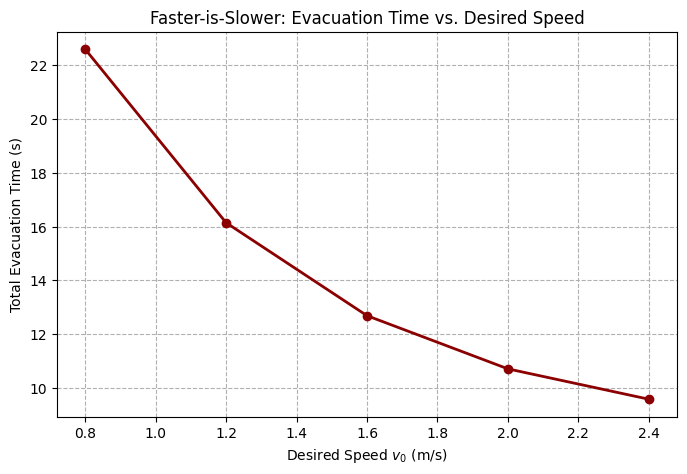

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(v0_values, evac_times, marker='o', color='darkred', linewidth=2)
plt.xlabel("Desired Speed $v_0$ (m/s)")
plt.ylabel("Total Evacuation Time (s)")
plt.title("Faster-is-Slower: Evacuation Time vs. Desired Speed")
plt.grid(True, linestyle='--')
plt.show()